In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device : {device}")

 Device : cpu


 500 images synthétiques générées
Classes : ['erythema', 'hyperpigmentation', 'wound', 'edema', 'normal']
Shape : (500, 224, 224, 3)


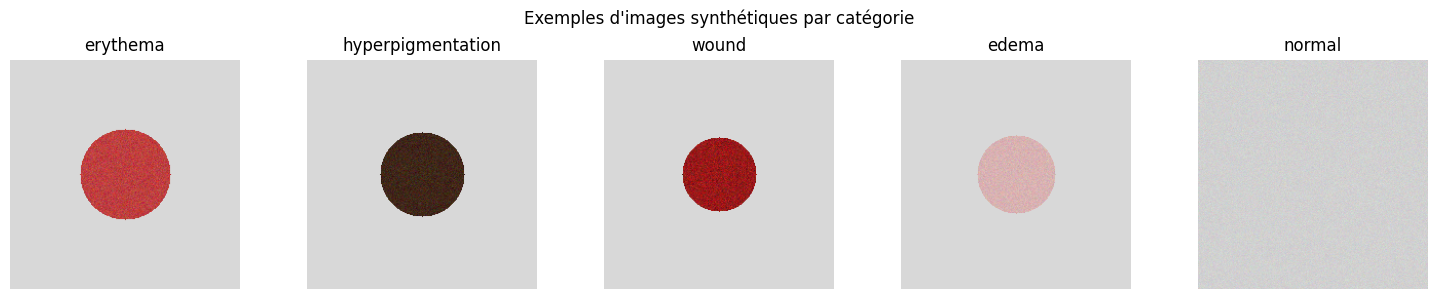

In [2]:
def generate_synthetic_lesion(category: str, size: int = 224) -> np.ndarray:
    """
    Génère une image synthétique simulant une lésion cutanée.
    Chaque catégorie a un profil colorimétrique distinct.
    En production : remplacer par de vraies images annotées.
    """
    img = np.ones((size, size, 3), dtype=np.float32) * 0.85  # fond clair

    cx, cy = size // 2, size // 2
    radius = np.random.randint(30, 70)

    # Création d'un masque circulaire pour la lésion
    Y, X = np.ogrid[:size, :size]
    dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
    mask = dist <= radius

    if category == "erythema":
        # Rouge vif avec légère variation
        img[mask, 0] = np.clip(0.75 + np.random.normal(0, 0.05, mask.sum()), 0, 1)
        img[mask, 1] = np.clip(0.25 + np.random.normal(0, 0.05, mask.sum()), 0, 1)
        img[mask, 2] = np.clip(0.25 + np.random.normal(0, 0.05, mask.sum()), 0, 1)

    elif category == "hyperpigmentation":
        # Brun foncé
        img[mask, 0] = np.clip(0.25 + np.random.normal(0, 0.04, mask.sum()), 0, 1)
        img[mask, 1] = np.clip(0.15 + np.random.normal(0, 0.04, mask.sum()), 0, 1)
        img[mask, 2] = np.clip(0.10 + np.random.normal(0, 0.04, mask.sum()), 0, 1)

    elif category == "wound":
        # Rouge sombre avec fort contraste (bords nets)
        img[mask, 0] = np.clip(0.60 + np.random.normal(0, 0.08, mask.sum()), 0, 1)
        img[mask, 1] = np.clip(0.10 + np.random.normal(0, 0.04, mask.sum()), 0, 1)
        img[mask, 2] = np.clip(0.10 + np.random.normal(0, 0.04, mask.sum()), 0, 1)

    elif category == "edema":
        # Rose pâle uniforme
        img[mask, 0] = np.clip(0.85 + np.random.normal(0, 0.03, mask.sum()), 0, 1)
        img[mask, 1] = np.clip(0.70 + np.random.normal(0, 0.03, mask.sum()), 0, 1)
        img[mask, 2] = np.clip(0.70 + np.random.normal(0, 0.03, mask.sum()), 0, 1)

    else:  # normal
        img[:, :, :] = np.clip(0.82 + np.random.normal(0, 0.02, (size, size, 3)), 0, 1)

    return (img * 255).astype(np.uint8)


# Génération du dataset synthétique
CATEGORIES = ["erythema", "hyperpigmentation", "wound", "edema", "normal"]
N_PER_CLASS = 100

synthetic_images = []
synthetic_labels = []

for label_idx, category in enumerate(CATEGORIES):
    for _ in range(N_PER_CLASS):
        img_array = generate_synthetic_lesion(category)
        synthetic_images.append(img_array)
        synthetic_labels.append(label_idx)

synthetic_images = np.array(synthetic_images)
synthetic_labels = np.array(synthetic_labels)

print(f" {len(synthetic_images)} images synthétiques générées")
print(f"Classes : {CATEGORIES}")
print(f"Shape : {synthetic_images.shape}")

# Visualisation d'exemples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, cat in enumerate(CATEGORIES):
    idx = np.where(np.array(synthetic_labels) == i)[0][0]
    axes[i].imshow(synthetic_images[idx])
    axes[i].set_title(cat)
    axes[i].axis("off")
plt.suptitle("Exemples d'images synthétiques par catégorie", fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
class LesionDataset(Dataset):
    """Dataset PyTorch pour images de lésions cutanées."""

    def __init__(self, images: np.ndarray, labels: np.ndarray, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label


# Transformations : normalisation ImageNet standard
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Split 80/20
split_idx = int(len(synthetic_images) * 0.8)
indices = np.random.permutation(len(synthetic_images))

train_imgs = synthetic_images[indices[:split_idx]]
train_lbls = synthetic_labels[indices[:split_idx]]
val_imgs = synthetic_images[indices[split_idx:]]
val_lbls = synthetic_labels[indices[split_idx:]]

train_dataset = LesionDataset(train_imgs, train_lbls, train_transform)
val_dataset = LesionDataset(val_imgs, val_lbls, val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f" Train : {len(train_dataset)} images | Val : {len(val_dataset)} images")

 Train : 400 images | Val : 100 images


In [4]:
# Chargement de MobileNetV2 pré-entraîné sur ImageNet
# Le transfer learning nous permet d'utiliser des features visuelles
# déjà apprises sur des millions d'images → gain énorme sur petit dataset
base_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Gel des couches de base (on ne ré-entraîne pas tout)
for param in base_model.features.parameters():
    param.requires_grad = False

# Remplacement de la tête de classification
# MobileNetV2 original : 1000 classes ImageNet
# Notre version : 5 classes de lésions
base_model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(base_model.last_channel, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, len(CATEGORIES))
)

model_cnn = base_model.to(device)

# Seuls les paramètres de la nouvelle tête sont entraînables
trainable_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_cnn.parameters())
print(f" MobileNetV2 chargé")
print(f"Paramètres totaux     : {total_params:,}")
print(f"Paramètres entraînables : {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\LASANTSY/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████████████████████████████████████████████████████████████████████████| 13.6M/13.6M [01:24<00:00, 169kB/s]


 MobileNetV2 chargé
Paramètres totaux     : 2,388,485
Paramètres entraînables : 164,613 (6.9%)


In [5]:
optimizer_cnn = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_cnn.parameters()),
    lr=0.001
)
criterion_cnn = nn.CrossEntropyLoss()
EPOCHS_CNN = 15

train_accs, val_accs = [], []
best_val_acc = 0.0

print(f" Entraînement MobileNetV2 sur {EPOCHS_CNN} epochs\n")

for epoch in range(EPOCHS_CNN):
    # Train
    model_cnn.train()
    correct, total = 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_cnn.zero_grad()
        outputs = model_cnn(imgs)
        loss = criterion_cnn(outputs, labels)
        loss.backward()
        optimizer_cnn.step()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total

    # Validation
    model_cnn.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model_cnn(imgs)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_cnn.state_dict(), "../ml_models/image/best_mobilenetv2.pth")

    if (epoch + 1) % 3 == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_CNN} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

print(f"\n Meilleure Val Accuracy : {best_val_acc:.3f}")

 Entraînement MobileNetV2 sur 15 epochs

Epoch  3/15 | Train Acc: 0.890 | Val Acc: 0.830
Epoch  6/15 | Train Acc: 0.905 | Val Acc: 1.000
Epoch  9/15 | Train Acc: 0.875 | Val Acc: 0.840
Epoch 12/15 | Train Acc: 0.920 | Val Acc: 1.000
Epoch 15/15 | Train Acc: 0.932 | Val Acc: 1.000

 Meilleure Val Accuracy : 1.000


In [6]:
os.makedirs("../ml_models/image", exist_ok=True)

cnn_config = {
    "architecture": "MobileNetV2",
    "num_classes": len(CATEGORIES),
    "categories": CATEGORIES,
    "input_size": 224,
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225]
}

with open("../ml_models/image/model_config.json", "w") as f:
    json.dump(cnn_config, f, indent=2)

print(" Modèle CNN sauvegardé :")
print("  → ml_models/image/best_mobilenetv2.pth")
print("  → ml_models/image/model_config.json")

 Modèle CNN sauvegardé :
  → ml_models/image/best_mobilenetv2.pth
  → ml_models/image/model_config.json


In [9]:
import re
import pickle
import json
import os
from typing import Optional
from datetime import datetime

# ---------------------------------------------------------------------------
# Gestion des chemins pour environnement notebook
# ---------------------------------------------------------------------------

# Définir les chemins des modèles (à ajuster selon votre structure)
# Option 1: Si le notebook est à la racine du projet
_MODEL_PATH = "../ml_models/text/tfidf_logreg_classifier.pkl"
_LABEL_PATH = "../ml_models/text/label_mapping.json"

# Option 2: Si le notebook est dans un sous-dossier 'notebooks'
# Décommentez les lignes suivantes si nécessaire
# import os
# if not os.path.exists(_MODEL_PATH):
#     _MODEL_PATH = "../" + _MODEL_PATH
#     _LABEL_PATH = "../" + _LABEL_PATH

_nlp_pipeline = None
_label_to_category = None
_category_to_label = None
_model_loaded = False


def _load_model():
    """Charge le modèle NLP depuis le disque (lazy loading)."""
    global _nlp_pipeline, _label_to_category, _category_to_label, _model_loaded

    if _model_loaded:
        return True

    try:
        with open(_MODEL_PATH, "rb") as f:
            _nlp_pipeline = pickle.load(f)
        with open(_LABEL_PATH, "r") as f:
            mapping = json.load(f)
            _label_to_category = {int(k): v for k, v in mapping["label_to_category"].items()}
            _category_to_label = mapping["category_to_label"]
        _model_loaded = True
        print(" Modèle NLP chargé depuis", _MODEL_PATH)
        return True
    except FileNotFoundError as e:
        print(f" Modèle NLP introuvable: {e}")
        print(f"   Chemin cherché: {_MODEL_PATH}")
        print(f"   Répertoire courant: {os.getcwd()}")
        print("   Fallback sur règles expertes")
        return False


# ---------------------------------------------------------------------------
# Fallback : règles expertes (utilisées si le modèle n'est pas disponible)
# ---------------------------------------------------------------------------

CARDIO_KEYWORDS = [
    "douleur thoracique", "oppression", "palpitations", "dyspnée",
    "essoufflement", "oedème", "oedeme", "tachycardie", "bradycardie",
    "syncope", "malaise", "angine", "infarctus", "insuffisance cardiaque"
]
METABOLIC_KEYWORDS = [
    "glycémie", "glycemie", "diabète", "diabete", "hyperglycémie",
    "hypoglycémie", "obésité", "obesite", "cholestérol", "cholesterol",
    "triglycérides", "syndrome métabolique", "insuline"
]
INFECTIOUS_KEYWORDS = [
    "fièvre", "fievre", "infection", "inflammatoire", "sepsis",
    "antibiotique", "bactérie", "bacterie", "virus", "grippe",
    "covid", "pneumonie", "cystite", "angine infectieuse"
]
NEUROLOGICAL_KEYWORDS = [
    "céphalée", "cephalee", "migraine", "vertige", "confusion",
    "désorientation", "convulsion", "AVC", "accident vasculaire",
    "paresthésie", "tremblements"
]
SEVERITY_MODIFIERS = {
    "high":   ["sévère", "severe", "aigu", "aiguë", "critique", "urgent", "grave", "brutal"],
    "medium": ["modéré", "modere", "persistant", "chronique", "récurrent"],
    "low":    ["léger", "leger", "bénin", "benin", "passager", "occasionnel"]
}
SUGGESTED_QUESTIONS = {
    "cardio": [
        "La douleur irradie-t-elle vers le bras gauche ou la mâchoire ?",
        "Avez-vous des antécédents familiaux de maladies cardiaques ?",
        "La douleur apparaît-elle à l'effort ou au repos ?",
        "Prenez-vous des anticoagulants ou antiplaquettaires ?"
    ],
    "metabolic": [
        "Avez-vous mesuré votre glycémie à jeun récemment ?",
        "Votre alimentation a-t-elle changé ces dernières semaines ?",
        "Ressentez-vous une soif excessive ou une fatigue inhabituelle ?",
        "Vos traitements antidiabétiques sont-ils pris régulièrement ?"
    ],
    "infectious": [
        "Depuis combien de jours avez-vous de la fièvre ?",
        "Avez-vous été en contact avec des personnes malades ?",
        "Avez-vous pris des antibiotiques récemment ?",
        "Avez-vous des frissons ou des sueurs nocturnes ?"
    ],
    "neurological": [
        "Les céphalées sont-elles nouvelles ou récurrentes ?",
        "Avez-vous eu des troubles visuels ou auditifs associés ?",
        "La douleur est-elle pulsatile ou en pression ?",
        "Y a-t-il des facteurs déclenchants identifiés ?"
    ]
}
SUGGESTED_EXAMS = {
    "cardio":       ["ECG", "Troponine", "BNP/NT-proBNP", "Échographie cardiaque"],
    "metabolic":    ["Glycémie à jeun", "HbA1c", "Bilan lipidique", "TSH"],
    "infectious":   ["NFS", "CRP", "Hémocultures", "ECBU", "PCR grippe/COVID"],
    "neurological": ["IRM cérébrale", "EEG", "Fond d'œil"]
}


def _normalize_text(text: str) -> str:
    """Normalise le texte pour l'analyse par règles."""
    text = text.lower().strip()
    text = re.sub(r"[^\w\sàâäéèêëîïôöùûüç\-]", " ", text)
    return re.sub(r"\s+", " ", text)


def _rule_based_analysis(note_text: str) -> dict:
    """Analyse par règles expertes (fallback si modèle absent)."""
    normalized = _normalize_text(note_text)
    severity = "medium"
    for level, mods in SEVERITY_MODIFIERS.items():
        if any(m in normalized for m in mods):
            severity = level
            break

    categories = {
        "cardio":       CARDIO_KEYWORDS,
        "metabolic":    METABOLIC_KEYWORDS,
        "infectious":   INFECTIOUS_KEYWORDS,
        "neurological": NEUROLOGICAL_KEYWORDS,
    }

    risk_scores, alerts, active_categories = [], [], []

    for cat, keywords in categories.items():
        matches = sum(1 for kw in keywords if kw in normalized)
        if matches == 0:
            continue
        score = min(1.0, 0.2 + matches * 0.25)
        level = "high" if (severity == "high" and score > 0.3) or score >= 0.7 \
            else "medium" if score >= 0.4 else "low"
        risk_scores.append({
            "category": cat, "label": cat.capitalize(),
            "level": level, "score": round(score, 2),
            "explanation": f"{matches} indicateur(s) détecté(s) (règles expertes)"
        })
        active_categories.append(cat)
        if level == "high":
            alerts.append({
                "type": cat, "severity": "critical",
                "message": f"Risque {cat} élevé détecté",
                "recommendation": f"Bilan urgent : {', '.join(SUGGESTED_EXAMS.get(cat, [])[:2])}"
            })
        elif level == "medium":
            alerts.append({
                "type": cat, "severity": "warning",
                "message": f"Signaux {cat} à surveiller",
                "recommendation": "Suivi recommandé dans les 7 jours"
            })

    suggested_questions, suggested_exams = [], []
    for cat in active_categories[:2]:
        suggested_questions.extend(SUGGESTED_QUESTIONS.get(cat, [])[:2])
        suggested_exams.extend(SUGGESTED_EXAMS.get(cat, [])[:3])

    summary = (
        f"[Règles expertes] {len(active_categories)} catégorie(s) détectée(s) : "
        f"{', '.join(active_categories)}. Sévérité : {severity}."
        if active_categories else "Aucun indicateur de risque détecté."
    )

    return {
        "risk_scores": risk_scores, "alerts": alerts,
        "suggested_questions": list(dict.fromkeys(suggested_questions)),
        "suggested_exams": list(dict.fromkeys(suggested_exams)),
        "summary": summary, "model_used": "rule_based"
    }


def _ml_based_analysis(note_text: str) -> dict:
    """Analyse par modèle ML entraîné (TF-IDF + LogReg)."""
    pred_label = int(_nlp_pipeline.predict([note_text])[0])
    pred_proba = _nlp_pipeline.predict_proba([note_text])[0]
    pred_category = _label_to_category[pred_label]
    confidence = float(pred_proba[pred_label])

    # Conversion en format risk_scores unifié
    risk_scores = []
    label_names = list(_category_to_label.keys())

    for i, cat in enumerate(_label_to_category.values()):
        if cat == "normal":
            continue
        score = float(pred_proba[i])
        if score < 0.05:
            continue
        level = "high" if score >= 0.7 else "medium" if score >= 0.35 else "low"
        risk_scores.append({
            "category": cat,
            "label": cat.capitalize(),
            "level": level,
            "score": round(score, 2),
            "explanation": f"Modèle ML — probabilité : {round(score*100, 1)}%"
        })

    risk_scores.sort(key=lambda x: x["score"], reverse=True)

    # Génération alertes sur catégorie principale
    alerts = []
    if pred_category != "normal" and confidence > 0.5:
        severity = "critical" if confidence > 0.8 else "warning"
        alerts.append({
            "type": pred_category,
            "severity": severity,
            "message": f"Catégorie principale : {pred_category} (confiance {round(confidence*100,1)}%)",
            "recommendation": f"Bilans suggérés : {', '.join(SUGGESTED_EXAMS.get(pred_category, [])[:2])}"
        })

    suggested_questions = SUGGESTED_QUESTIONS.get(pred_category, [])[:3]
    suggested_exams = SUGGESTED_EXAMS.get(pred_category, [])[:4]

    summary = (
        f"[Modèle ML] Catégorie principale : {pred_category.upper()} "
        f"(confiance {round(confidence*100, 1)}%). "
        f"Analysé le {datetime.now().strftime('%d/%m/%Y à %H:%M')}."
    )

    return {
        "risk_scores": risk_scores, "alerts": alerts,
        "suggested_questions": suggested_questions,
        "suggested_exams": suggested_exams,
        "summary": summary, "model_used": "ml_tfidf_logreg",
        "predicted_category": pred_category,
        "confidence": round(confidence, 3)
    }


def analyze_consultation_text(note_text: str) -> dict:
    """
    Point d'entrée principal du service NLP.
    Utilise le modèle ML si disponible, sinon fallback règles expertes.
    
    Args:
        note_text (str): Texte de la note de consultation
        
    Returns:
        dict: Résultats de l'analyse incluant scores de risque, alertes, etc.
    """
    if not note_text or len(note_text.strip()) < 5:
        return {
            "risk_scores": [], "alerts": [],
            "suggested_questions": [], "suggested_exams": [],
            "summary": "Note trop courte pour analyse.",
            "model_used": "none"
        }

    model_available = _load_model()

    if model_available and _nlp_pipeline is not None:
        return _ml_based_analysis(note_text)
    else:
        return _rule_based_analysis(note_text)


# ---------------------------------------------------------------------------
# Exemple d'utilisation (à décommenter pour tester)
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    # Test avec un exemple de note
    test_note = "Patient présente une douleur thoracique avec essoufflement et palpitations. Antécédents d'hypertension."
    
    result = analyze_consultation_text(test_note)
    
    print("\n" + "="*50)
    print("RÉSULTATS DE L'ANALYSE")
    print("="*50)
    print(f"Modèle utilisé : {result['model_used']}")
    print(f"\nRésumé : {result['summary']}")
    
    if result['risk_scores']:
        print("\nScores de risque :")
        for score in result['risk_scores']:
            print(f"  - {score['label']}: {score['level']} (score: {score['score']})")
    
    if result['alerts']:
        print("\nAlertes :")
        for alert in result['alerts']:
            print(f"  - [{alert['severity'].upper()}] {alert['message']}")
    
    if result['suggested_questions']:
        print("\nQuestions suggérées :")
        for q in result['suggested_questions']:
            print(f"  • {q}")
    
    if result['suggested_exams']:
        print("\nExamens suggérés :")
        for e in result['suggested_exams']:
            print(f"  • {e}")

 Modèle NLP chargé depuis ../ml_models/text/tfidf_logreg_classifier.pkl

RÉSULTATS DE L'ANALYSE
Modèle utilisé : ml_tfidf_logreg

Résumé : [Modèle ML] Catégorie principale : CARDIO (confiance 50.8%). Analysé le 21/04/2026 à 14:18.

Scores de risque :
  - Cardio: medium (score: 0.51)
  - Metabolic: low (score: 0.17)
  - Infectious: low (score: 0.13)

Alertes :
  - [WARNING] Catégorie principale : cardio (confiance 50.8%)

Questions suggérées :
  • La douleur irradie-t-elle vers le bras gauche ou la mâchoire ?
  • Avez-vous des antécédents familiaux de maladies cardiaques ?
  • La douleur apparaît-elle à l'effort ou au repos ?

Examens suggérés :
  • ECG
  • Troponine
  • BNP/NT-proBNP
  • Échographie cardiaque
